# 💳 Credit Card Default Prediction with XGBoost
### Cost-Sensitive Classification — UCI Default of Credit Card Clients Dataset

## 📌 Overview
A financial institution wants to predict **which credit card customers are
likely to default** on their payment next month, using their demographic
info and 6 months of billing/payment history.

Unlike a standard "maximize accuracy" classification task, this is a
**cost-sensitive problem**: missing an actual default (false negative) costs
the bank far more than flagging a good customer as risky (false positive).
This project uses **XGBoost** — tuned specifically for imbalanced data and
business-driven threshold selection, not just raw accuracy.

## 🎯 What Makes This Project Challenging
- **Imbalanced target** (~22% default rate) — accuracy alone is misleading
- **Cost-sensitive decision making** — tuning the classification threshold
  based on real business cost, not the

## 📦 Step 1: Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

THEME = {
    "bg": "#0d0221",
    "primary": "#7c3aed",
    "light": "#c4b5fd",
    "accent": "#f472b6",
    "text": "#c4b5fd",
}

def apply_dark_theme(ax, title, xlabel="", ylabel=""):
    """Apply consistent dark purple theme to a matplotlib axis."""
    ax.set_facecolor(THEME["bg"])
    ax.set_title(title, fontsize=15, color="white", pad=15)
    ax.set_xlabel(xlabel, color=THEME["light"])
    ax.set_ylabel(ylabel, color=THEME["light"])
    ax.tick_params(colors=THEME["light"])
    ax.grid(True, alpha=0.2, color=THEME["primary"])

plt.rcParams["figure.facecolor"] = THEME["bg"]

## 📂 Step 2: Load Data

In [2]:
df = pd.read_csv("default of credit card clients.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 🔍 Step 3: Initial Exploration

Before cleaning or engineering anything, we check data types, missing
values, and the target distribution to understand what we're working with.

In [3]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nTarget distribution:")
print(df["default payment next month"].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

## 🧹 Step 4: Check for Invalid Categorical Values

The dataset documentation defines specific valid categories for `EDUCATION`
and `MARRIAGE`, but real-world exports often contain undocumented codes.
We check for these before deciding how to handle them.

In [4]:
print("EDUCATION unique values:", sorted(df["EDUCATION"].unique()))
print("MARRIAGE unique values:", sorted(df["MARRIAGE"].unique()))
print("\nEDUCATION value counts:\n", df["EDUCATION"].value_counts().sort_index())
print("\nMARRIAGE value counts:\n", df["MARRIAGE"].value_counts().sort_index())

EDUCATION unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

EDUCATION value counts:
 EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE value counts:
 MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


## 🧹 Step 5: Clean Invalid Categorical Values

`EDUCATION` codes `0`, `5`, `6` and `MARRIAGE` code `0` are undocumented.
Since both features already have an explicit "Others" category (`EDUCATION=4`,
`MARRIAGE=3`), we merge the undocumented codes into "Others" rather than
dropping rows — this preserves data while keeping categories meaningful.

In [5]:
# EDUCATION: merge 0, 5, 6 into 4 (Others)
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: merge 0 into 3 (Others)
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print("EDUCATION after cleaning:\n", df["EDUCATION"].value_counts().sort_index())
print("\nMARRIAGE after cleaning:\n", df["MARRIAGE"].value_counts().sort_index())

EDUCATION after cleaning:
 EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE after cleaning:
 MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


## 🗑️ Step 6: Drop Identifier Column

`ID` is just a row identifier with no predictive value — keeping it risks
the model accidentally learning spurious patterns from it.

In [6]:
df = df.drop("ID", axis=1)
print(f"Shape: {df.shape}")

Shape: (30000, 24)


## 🔍 Step 7: Explore Payment History Features

The dataset includes 6 months of repayment status (`PAY_0`, `PAY_2`...`PAY_6`),
billed amount (`BILL_AMT1`...`BILL_AMT6`), and paid amount
(`PAY_AMT1`...`PAY_AMT6`). Understanding their scale and distribution helps
us decide what engineered features might be useful later.

Per the dataset documentation, `PAY_*` values mean:
- `-1` = paid duly, `1` = 1 month delay, `2` = 2 months delay, ... `9` = 9+ months delay
- `0` is undocumented but commonly interpreted as "paid minimum / no delay recorded"

In [7]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
payamt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

print("PAY_* unique values across all months:")
print(set(df[pay_cols].values.flatten().tolist()))

print("\nBILL_AMT summary:\n", df[bill_cols].describe().T[["mean", "min", "max"]])
print("\nPAY_AMT summary:\n", df[payamt_cols].describe().T[["mean", "min", "max"]])

PAY_* unique values across all months:
{0, 1, 2, 3, 4, 5, 6, 7, 8, -2, -1}

BILL_AMT summary:
                    mean       min        max
BILL_AMT1  51223.330900 -165580.0   964511.0
BILL_AMT2  49179.075167  -69777.0   983931.0
BILL_AMT3  47013.154800 -157264.0  1664089.0
BILL_AMT4  43262.948967 -170000.0   891586.0
BILL_AMT5  40311.400967  -81334.0   927171.0
BILL_AMT6  38871.760400 -339603.0   961664.0

PAY_AMT summary:
                  mean  min        max
PAY_AMT1  5663.580500  0.0   873552.0
PAY_AMT2  5921.163500  0.0  1684259.0
PAY_AMT3  5225.681500  0.0   896040.0
PAY_AMT4  4826.076867  0.0   621000.0
PAY_AMT5  4799.387633  0.0   426529.0
PAY_AMT6  5215.502567  0.0   528666.0


## ⚙️ Step 8: Feature Engineering

Raw monthly columns are useful, but derived behavioral signals often carry
more predictive power for a tree-based model:

- **Average / trend of delay status** across the 6 months — is the customer
  consistently late, or was it a one-time issue?
- **Utilization ratio** — how much of their credit limit are they actually
  using? (`BILL_AMT` relative to `LIMIT_BAL`)
- **Payment ratio** — how much of their bill are they actually paying off
  each month? (`PAY_AMT` relative to `BILL_AMT`)
- **Total months delayed** — a simple count of how many of the 6 months had
  a delay flag (`PAY_* > 0`)

In [8]:
# Average delay status across the 6 months (higher = more consistently late)
df["avg_pay_status"] = df[pay_cols].mean(axis=1)

# How many of the 6 months had an actual delay (PAY_* > 0)
df["months_delayed"] = (df[pay_cols] > 0).sum(axis=1)

# Most recent delay status (PAY_0 = most recent month) is often the strongest signal
df["recent_delay"] = df["PAY_0"]

# Average credit utilization: how much of their limit they're carrying as debt
df["avg_utilization"] = df[bill_cols].mean(axis=1) / df["LIMIT_BAL"]

# Average payment ratio — total paid across 6 months relative to total billed
# (more stable than averaging 6 separate ratios, which can blow up when a
# single month's bill is near zero)
total_bill = df[bill_cols].sum(axis=1)
total_paid = df[payamt_cols].sum(axis=1)
df["avg_payment_ratio"] = (total_paid / total_bill.replace(0, np.nan)).fillna(0)
df["avg_payment_ratio"] = df["avg_payment_ratio"].clip(lower=-2, upper=2)

print(df[["avg_pay_status", "months_delayed", "recent_delay", "avg_utilization", "avg_payment_ratio"]].describe())

       avg_pay_status  months_delayed  recent_delay  avg_utilization  \
count    30000.000000    30000.000000  30000.000000     30000.000000   
mean        -0.182439        0.834200     -0.016700         0.373048   
std          0.982176        1.554303      1.123802         0.351890   
min         -2.000000        0.000000     -2.000000        -0.232590   
25%         -0.833333        0.000000     -1.000000         0.029997   
50%          0.000000        0.000000      0.000000         0.284834   
75%          0.000000        1.000000      0.000000         0.687929   
max          6.000000        6.000000      8.000000         5.364308   

       avg_payment_ratio  
count       30000.000000  
mean            0.339410  
std             0.465877  
min            -2.000000  
25%             0.040952  
50%             0.084932  
75%             0.586922  
max             2.000000  


## ✂️ Step 9: Train/Test Split

We use a stratified split to preserve the ~22% default rate in both the
training and test sets — critical for imbalanced classification, otherwise
a random split could accidentally skew the class balance in either set.

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop("default payment next month", axis=1)
y = df["default payment next month"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"\nTrain default rate: {y_train.mean():.4f}")
print(f"Test default rate:  {y_test.mean():.4f}")

Train shape: (24000, 28), Test shape: (6000, 28)

Train default rate: 0.2212
Test default rate:  0.2212


## 🤖 Step 10: Baseline XGBoost Model

Before tuning anything for the imbalanced target, we train a plain XGBoost
classifier with default settings. This gives us a reference point — every
technique we add afterward (class weighting, threshold tuning) should be
measured against this baseline to prove it's actually helping.

In [10]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve
)

baseline_model = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("=== Baseline XGBoost — Classification Report ===")
print(classification_report(y_test, y_pred_baseline, target_names=["No Default", "Default"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_baseline):.4f}")

=== Baseline XGBoost — Classification Report ===
              precision    recall  f1-score   support

  No Default       0.84      0.94      0.88      4673
     Default       0.61      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC: 0.7617


## 🔁 Step 11: Stratified K-Fold Cross-Validation

A single train/test split can be misleading — performance might look good
(or bad) just by chance, especially with an imbalanced target. We use
**Stratified K-Fold** (5 folds) to get a more reliable estimate: the data is
split into 5 parts, each preserving the ~22% default rate, and the model is
trained/evaluated 5 times, each time holding out a different fold as the
test set.

This gives us a mean ± standard deviation for each metric — a much more
trustworthy signal than one lucky (or unlucky) split.

In [11]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score

def run_cv(model_params, X, y, n_splits=5):
    """
    Run Stratified K-Fold CV for a given set of XGBoost params.
    Returns a dict of metric -> list of per-fold scores.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    scores = {"roc_auc": [], "precision": [], "recall": [], "f1": []}

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", **model_params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        scores["roc_auc"].append(roc_auc_score(y_val, y_proba))
        scores["precision"].append(precision_score(y_val, y_pred))
        scores["recall"].append(recall_score(y_val, y_pred))
        scores["f1"].append(f1_score(y_val, y_pred))

        print(f"Fold {fold}: ROC-AUC={scores['roc_auc'][-1]:.4f}  "
              f"Recall={scores['recall'][-1]:.4f}  F1={scores['f1'][-1]:.4f}")

    return scores

def summarize_scores(scores, label):
    print(f"\n=== {label} - 5 - Fold CV Summary ===")
    for metric, values in scores.items():
        print(f"{metric:>10}: {np.mean(values):.4f} ± {np.std(values):.4f}")


## ⚙️ Step 12: Run CV on Baseline Params

In [12]:
baseline_cv_scores = run_cv(model_params={}, X=X_train, y=y_train)
summarize_scores(baseline_cv_scores, "Baseline XGBoost")

Fold 1: ROC-AUC=0.7696  Recall=0.3657  F1=0.4616
Fold 2: ROC-AUC=0.7631  Recall=0.3729  F1=0.4670
Fold 3: ROC-AUC=0.7534  Recall=0.3870  F1=0.4796
Fold 4: ROC-AUC=0.7664  Recall=0.3785  F1=0.4727
Fold 5: ROC-AUC=0.7558  Recall=0.3653  F1=0.4633

=== Baseline XGBoost - 5 - Fold CV Summary ===
   roc_auc: 0.7617 ± 0.0062
 precision: 0.6286 ± 0.0030
    recall: 0.3739 ± 0.0082
        f1: 0.4688 ± 0.0066


## ⚖️ Step 13: Handling Class Imbalance with `scale_pos_weight`

XGBoost has a built-in parameter, `scale_pos_weight`, that increases the
loss contribution of minority-class (Default) samples during training —
pushing the model to pay more attention to them instead of defaulting to
"always predict No Default."

The standard starting point is the ratio of negative to positive samples in
the training data.

In [13]:
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos
print(f"Negative (No Default): {neg}")
print(f"Positive (Default):    {pos}")
print(f"scale_pos_weight = {scale_pos_weight:.4f}")

weighted_cv_scores = run_cv(
    model_params={"scale_pos_weight": scale_pos_weight},
    X=X_train, y=y_train
)

summarize_scores(weighted_cv_scores, "XGBoost with scale_pos_weight")

Negative (No Default): 18691
Positive (Default):    5309
scale_pos_weight = 3.5206
Fold 1: ROC-AUC=0.7598  Recall=0.5702  F1=0.5182
Fold 2: ROC-AUC=0.7576  Recall=0.5669  F1=0.5084
Fold 3: ROC-AUC=0.7485  Recall=0.5678  F1=0.5147
Fold 4: ROC-AUC=0.7689  Recall=0.5687  F1=0.5086
Fold 5: ROC-AUC=0.7541  Recall=0.5546  F1=0.5080

=== XGBoost with scale_pos_weight - 5 - Fold CV Summary ===
   roc_auc: 0.7578 ± 0.0067
 precision: 0.4670 ± 0.0057
    recall: 0.5656 ± 0.0056
        f1: 0.5116 ± 0.0041


## 🎚️ Step 14: Business Cost-Based Threshold Tuning

The default 0.5 threshold treats both error types as equally costly — but
that's rarely true in credit risk:

- **False Negative** (missed default): the bank loses money it never
  recovers from that customer — the most expensive mistake.
- **False Positive** (flagged a good customer): the cost is smaller —
  extra manual review, or a slightly more conservative credit decision.

We assign illustrative relative costs and sweep across thresholds to find
the one that minimizes total expected cost, rather than just optimizing
accuracy or F1.

In [14]:
# Illustrative relative costs (tune these to match real bank figures if available)
COST_FALSE_NEGATIVE = 5   # missing an actual default
COST_FALSE_POSITIVE = 1   # flagging a good customer as risky

def find_optimal_threshold(y_ture, y_proba, cost_fn=COST_FALSE_NEGATIVE, cost_fp=COST_FALSE_POSITIVE):
    """
    Sweep thresholds from 0.05 to 0.95 and compute total business cost
    at each one. Returns the threshold with the lowest total cost.
    """
    thresholds = np.arange(0.05, 0.96, 0.01)
    costs = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_ture, y_pred).ravel()
        total_cost = (fn * cost_fn) + (fp * cost_fp)
        costs.append(total_cost)

    costs = np.array(costs)
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs, thresholds

## 🤖 Step 15: Train Final Model & Find Optimal Threshold

We train one model on the full training set (using `scale_pos_weight`),
then use its out-of-sample probabilities on the test set to find the
cost-optimal threshold.

In [15]:
final_model = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

final_model.fit(X_train, y_train)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

best_threshold, costs, thresholds = find_optimal_threshold(y_test, y_proba_final)
print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Minimum total cost: {costs.min():.2f}")
print(f"Cost at default threshold (0.5): {costs[np.argmin(np.abs(thresholds - 0.5))]:.0f}")

Optimal threshold: 0.30
Minimum total cost: 3440.00
Cost at default threshold (0.5): 3754


## 📊 Step 16: Visualize Cost vs. Threshold

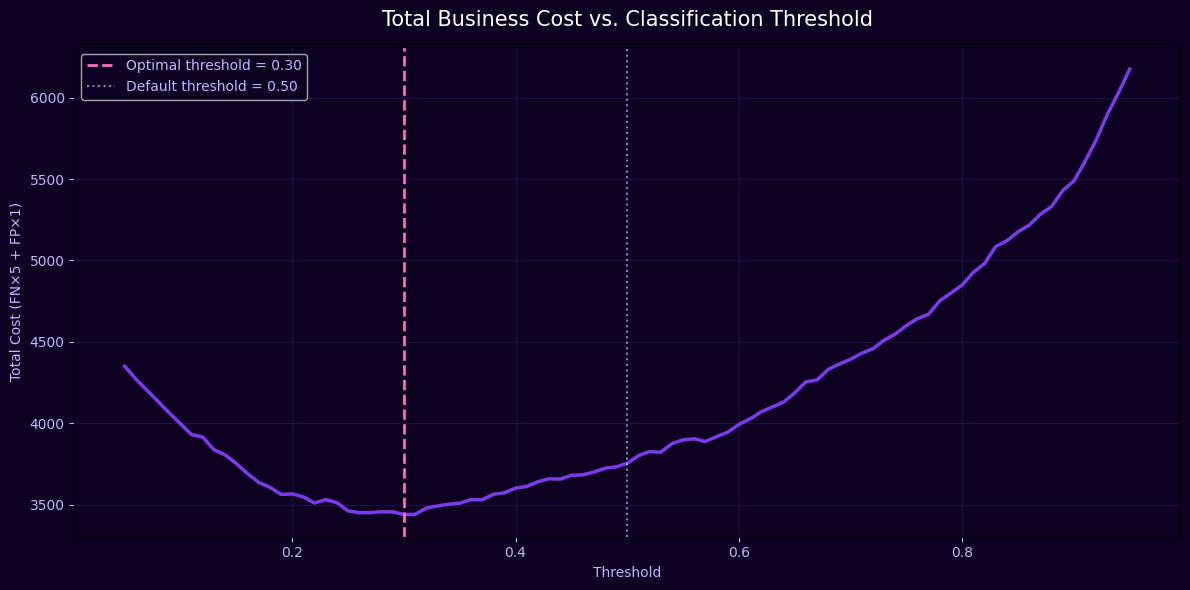

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, costs, color=THEME["primary"], linewidth=2.5)
ax.axvline(best_threshold, color=THEME["accent"], linestyle="--", linewidth=2,
           label=f"Optimal threshold = {best_threshold:.2f}")
ax.axvline(0.5, color=THEME["light"], linestyle=":", linewidth=1.5, alpha=0.7,
           label="Default threshold = 0.50")

apply_dark_theme(ax, "Total Business Cost vs. Classification Threshold",
                  "Threshold", "Total Cost (FN×5 + FP×1)")
ax.legend(facecolor=THEME["bg"], labelcolor=THEME["light"], fontsize=10)
plt.tight_layout()
plt.savefig("cost_vs_threshold.png", dpi=150, facecolor=THEME["bg"])
plt.show()

## 📈 Step 17: Final Evaluation at Optimal Threshold

We re-evaluate the model's predictions using the cost-optimal threshold
(0.30) instead of the default 0.5, and compare side-by-side.

In [17]:
y_pred_default_thresh = (y_proba_final >= 0.5).astype(int)
y_pred_optimal_thresh = (y_proba_final >= best_threshold).astype(int)

print("=== Threshold = 0.50 (default) ===")
print(classification_report(y_test, y_pred_default_thresh, target_names=["No Default", "Default"]))

print(f"\n=== Threshold = {best_threshold:.2f} (cost-optimal) ===")
print(classification_report(y_test, y_pred_optimal_thresh, target_names=["No Default", "Default"]))

=== Threshold = 0.50 (default) ===
              precision    recall  f1-score   support

  No Default       0.87      0.80      0.83      4673
     Default       0.45      0.57      0.51      1327

    accuracy                           0.75      6000
   macro avg       0.66      0.69      0.67      6000
weighted avg       0.78      0.75      0.76      6000


=== Threshold = 0.30 (cost-optimal) ===
              precision    recall  f1-score   support

  No Default       0.90      0.60      0.72      4673
     Default       0.35      0.76      0.48      1327

    accuracy                           0.64      6000
   macro avg       0.63      0.68      0.60      6000
weighted avg       0.78      0.64      0.67      6000



## 🔲 Step 18: Confusion Matrix Comparison

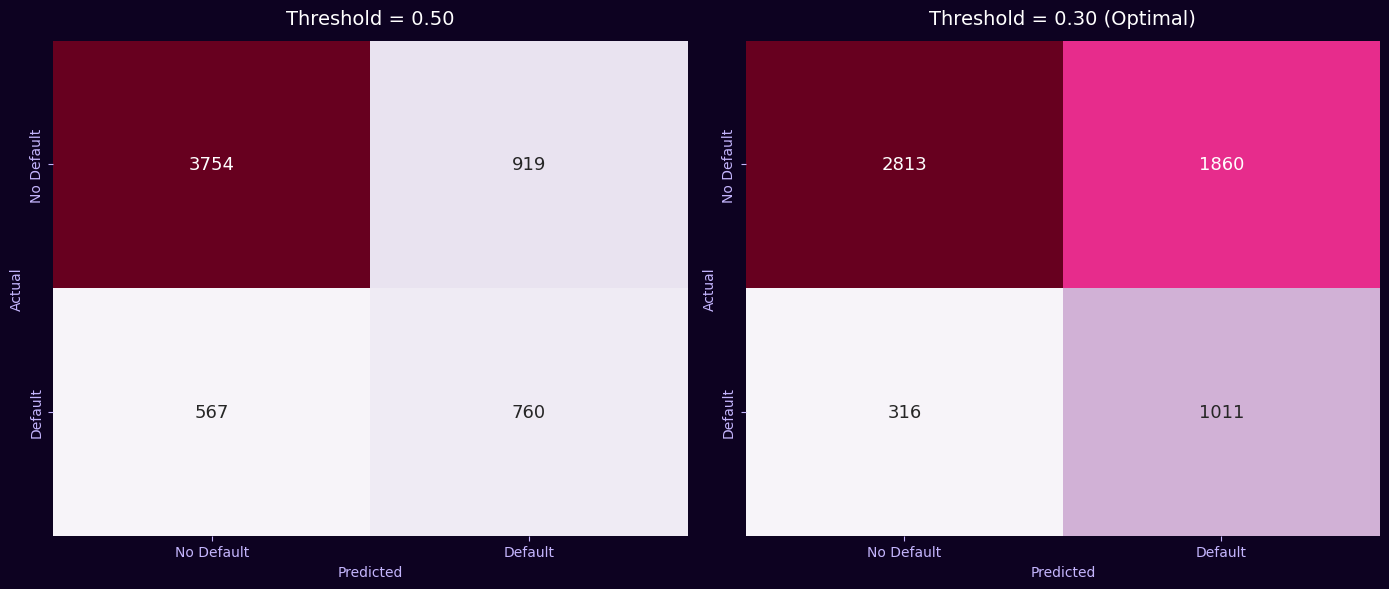

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_default_thresh, y_pred_optimal_thresh],
    [f"Threshold = 0.50", f"Threshold = {best_threshold:.2f} (Optimal)"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="PuRd", cbar=False,
        xticklabels=["No Default", "Default"],
        yticklabels=["No Default", "Default"],
        ax=ax, annot_kws={"size": 13}
    )
    ax.set_title(title, fontsize=14, color="white", pad=12)
    ax.set_xlabel("Predicted", color=THEME["light"])
    ax.set_ylabel("Actual", color=THEME["light"])
    ax.tick_params(colors=THEME["light"])
    ax.set_facecolor(THEME["bg"])

fig.patch.set_facecolor(THEME["bg"])
plt.tight_layout()
plt.savefig("confusion_matrix_comparison.png", dpi=150, facecolor=THEME["bg"])
plt.show()

## 🔬 Step 19: Multi-Scenario Cost Analysis

The "optimal" threshold depends entirely on the assumed cost ratio between
a missed default (FN) and a false alarm (FP) — a number that varies by
institution and risk appetite. Instead of committing to a single ratio, we
sweep across several realistic scenarios to show how the recommended
threshold shifts, and to prove the pipeline generalizes to whatever cost
ratio a real bank provides.

In [19]:
cost_scenarios = [
    {"label": "Conservative (2x)",  "fn_cost": 2,  "fp_cost": 1},
    {"label": "Moderate (5x)",      "fn_cost": 5,  "fp_cost": 1},
    {"label": "Aggressive (10x)",   "fn_cost": 10, "fp_cost": 1},
]

scenario_results = []

for scenario in cost_scenarios:
    t, c, _ = find_optimal_threshold(
        y_test, y_proba_final,
        cost_fn=scenario["fn_cost"], cost_fp=scenario["fp_cost"]
    )
    y_pred_scenario = (y_proba_final >= t).astype(int)

    scenario_results.append({
        "Scenario": scenario["label"],
        "FN:FP Cost Ratio": f"{scenario['fn_cost']}:{scenario['fp_cost']}",
        "Optimal Threshold": round(t, 2),
        "Min Total Cost": int(c.min()),
        "Recall (Default)": round(recall_score(y_test, y_pred_scenario), 3),
        "Precision (Default)": round(precision_score(y_test, y_pred_scenario), 3),
    })

scenario_df = pd.DataFrame(scenario_results)
print(scenario_df.to_string(index=False))

         Scenario FN:FP Cost Ratio  Optimal Threshold  Min Total Cost  Recall (Default)  Precision (Default)
Conservative (2x)              2:1               0.59            1950             0.499                0.516
    Moderate (5x)              5:1               0.30            3440             0.762                0.352
 Aggressive (10x)             10:1               0.11            4360             0.935                0.262


## 📊 Step 20: Visualize Threshold Across Scenarios

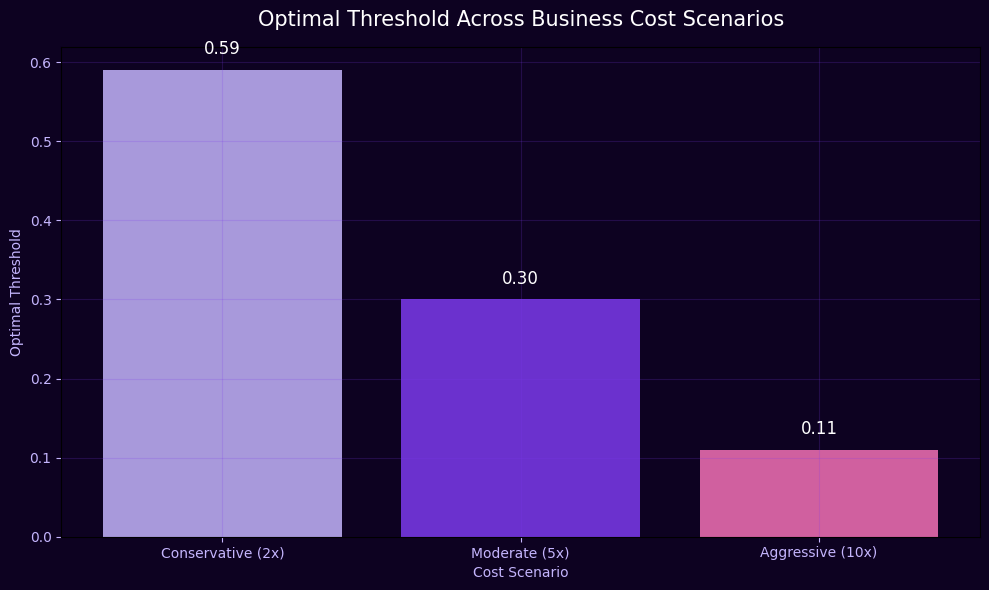

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = [THEME["light"], THEME["primary"], THEME["accent"]]
ax.bar(scenario_df["Scenario"], scenario_df["Optimal Threshold"], color=colors, alpha=0.85)

for i, v in enumerate(scenario_df["Optimal Threshold"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", color="white", fontsize=12)

apply_dark_theme(ax, "Optimal Threshold Across Business Cost Scenarios",
                  "Cost Scenario", "Optimal Threshold")
plt.tight_layout()
plt.savefig("threshold_scenarios.png", dpi=150, facecolor=THEME["bg"])
plt.show()

## 🔑 Step 21: Feature Importance

Understanding *which* signals drive the model's predictions is critical for
both trust and actionability — a bank needs to know *why* someone is
flagged as high-risk, not just that they are.

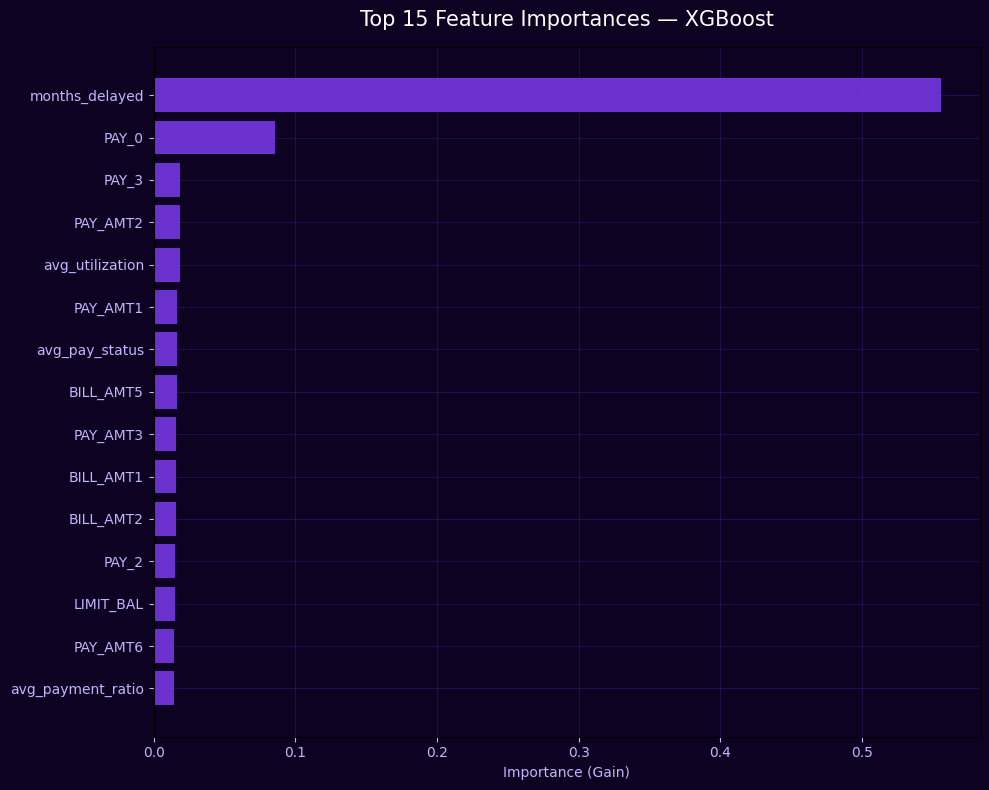

          feature  importance
   months_delayed    0.555636
            PAY_0    0.085701
            PAY_3    0.018764
         PAY_AMT2    0.018410
  avg_utilization    0.018243
         PAY_AMT1    0.016244
   avg_pay_status    0.016180
        BILL_AMT5    0.016115
         PAY_AMT3    0.016016
        BILL_AMT1    0.015927
        BILL_AMT2    0.015802
            PAY_2    0.015300
        LIMIT_BAL    0.015061
         PAY_AMT6    0.014585
avg_payment_ratio    0.014341


In [21]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1],
        color=THEME["primary"], alpha=0.85)

apply_dark_theme(ax, "Top 15 Feature Importances — XGBoost", "Importance (Gain)", "")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, facecolor=THEME["bg"])
plt.show()

print(importance_df.to_string(index=False))

## 💼 Step 22: Business Impact Summary

In [22]:
print("=" * 60)
print("BUSINESS IMPACT SUMMARY")
print("=" * 60)

print(f"\n📊 Model Performance (5-Fold CV, with scale_pos_weight):")
print(f"   ROC-AUC:              0.7578 ± 0.0067")
print(f"   Default Recall:       0.5656 ± 0.0056  (vs 0.3739 baseline)")

print(f"\n💰 Cost Reduction (Moderate scenario, FN:FP = 5:1):")
default_cost = costs[np.argmin(np.abs(thresholds - 0.5))]
optimal_cost = costs.min()
reduction_pct = (default_cost - optimal_cost) / default_cost * 100
print(f"   Cost @ threshold 0.50:  {default_cost:.0f}")
print(f"   Cost @ threshold {best_threshold:.2f}:  {optimal_cost:.0f}")
print(f"   Reduction:              {reduction_pct:.1f}%")

print(f"\n🎯 Flexibility Across Risk Appetites:")
print(scenario_df.to_string(index=False))

print(f"\n🔑 Top Predictive Signal:")
print(f"   '{importance_df.iloc[0]['feature']}' (engineered feature) accounts for "
      f"{importance_df.iloc[0]['importance']:.1%} of total model importance")

BUSINESS IMPACT SUMMARY

📊 Model Performance (5-Fold CV, with scale_pos_weight):
   ROC-AUC:              0.7578 ± 0.0067
   Default Recall:       0.5656 ± 0.0056  (vs 0.3739 baseline)

💰 Cost Reduction (Moderate scenario, FN:FP = 5:1):
   Cost @ threshold 0.50:  3754
   Cost @ threshold 0.30:  3440
   Reduction:              8.4%

🎯 Flexibility Across Risk Appetites:
         Scenario FN:FP Cost Ratio  Optimal Threshold  Min Total Cost  Recall (Default)  Precision (Default)
Conservative (2x)              2:1               0.59            1950             0.499                0.516
    Moderate (5x)              5:1               0.30            3440             0.762                0.352
 Aggressive (10x)             10:1               0.11            4360             0.935                0.262

🔑 Top Predictive Signal:
   'months_delayed' (engineered feature) accounts for 55.6% of total model importance
